## Classification par $k$ plus proches voisins ($k$-NN)

Dans ce notebook, nous appliquons un algorithme de classification basée sur les plus proches voisins ($k$-Nearest Neighbors).

### Démarche méthodologique :
1. **Mise à l'échelle (`StandardScaler`)** : Comme l'algorithme $k$-NN repose sur des calculs de distances (ex. distance euclidienne), la normalisation/standardisation des variables est indispensable pour éviter que les caractéristiques à forte variance ne dominent le modèle.
2. **Sélection de l'hyperparamètre $k$ (`n_neighbors`)** : Évaluation d'une plage de valeurs pour $k$ (ex. $k \in [1, 31]$) par validation croisée à 5 plis groupée et stratifiée.
3. **Évaluation globale** : Analyse des courbes de performance (score / erreur en fonction de $k$), extraction du meilleur modèle et sauvegarde dans `results.csv`.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate

from helpers.utils import (
    SEED, N_FOLDS, TARGETS, REPORT_FAMILIES, THRESHOLDS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, deposit_labels, evaluate, save_results,
)


In [26]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)


In [27]:
train = load_train()
print(f"Dataset d'entraînement chargé : {train.shape[0]} lignes, {train['input_group'].nunique()} groupes d'assemblage.")
for target in TARGETS:
    X, y, _ = get_xy(train, target)
    print(f"  Cible '{target}': {len(X)} lignes, {X.shape[1]} caractéristiques entrantes.")


Dataset d'entraînement chargé : 1332 lignes, 496 groupes d'assemblage.
  Cible 'yield_strength_MPa': 620 lignes, 30 caractéristiques entrantes.
  Cible 'uts_MPa': 596 lignes, 30 caractéristiques entrantes.
  Cible 'elongation_pct': 558 lignes, 30 caractéristiques entrantes.
  Cible 'charpy_toughness_J': 723 lignes, 31 caractéristiques entrantes.


### Pipeline $k$-NN & Recherche du $k$ optimal

Afin d'éviter tout phénomène de fuite d'information (*data leakage*), le `StandardScaler` est inclus dans le `Pipeline` à l'intérieur de la validation croisée.

In [28]:
def build_knn_pipeline(n_neighbors, weights="uniform", metric="minkowski"):
    """Construit un Pipeline incluant la standardisation et le classifieur k-NN."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, metric=metric))
    ])

def evaluate_knn_k_values(X, y, cv, k_range=range(1, 31)):
    """Évalue les performances de k-NN pour différentes valeurs de k."""
    history = []
    
    for k in k_range:
        pipeline = build_knn_pipeline(n_neighbors=k)
        cv_res = cross_validate(
            pipeline, X, y, cv=cv, 
            scoring="neg_mean_absolute_error", 
            return_train_score=True
        )
        
        train_mea = cv_res["train_score"].mean()
        val_mea = cv_res["test_score"].mean()
        val_mea_std = cv_res["test_score"].std()
        
        history.append({
            "k": k,
            "train_mea": train_mea,
            "val_mea": val_mea,
            "val_mea_std": val_mea_std
        })
        
    return pd.DataFrame(history)


### Évaluation et sélection du meilleur $k$ pour chaque cible

In [29]:
knn_histories = {}
best_knn_models = {}
best_k_values = {}

# Plage des valeurs de k à tester
k_search_range = range(1, 31)

for target in TARGETS:
    X, y, cv = get_xy(train, target)
    df_history = evaluate_knn_k_values(X, y, cv, k_range=k_search_range)
    knn_histories[target] = df_history
    
    # Sélection du k maximisant la précision (MEA) en validation
    best_row = df_history.loc[df_history["val_mea"].idxmax()]
    opt_k = int(best_row["k"])
    
    best_k_values[target] = opt_k
    best_knn_models[target] = build_knn_pipeline(n_neighbors=opt_k)
    
    print(f"Target '{target:20s}': Meilleur k = {opt_k:2d} | Val MEA = {best_row['val_mea']:.4f} (Train MEA = {best_row['train_mea']:.4f})")


Target 'yield_strength_MPa  ': Meilleur k =  2 | Val MEA = -39.4447 (Train MEA = -18.3535)
Target 'uts_MPa             ': Meilleur k =  2 | Val MEA = -33.9994 (Train MEA = -15.5755)
Target 'elongation_pct      ': Meilleur k =  2 | Val MEA = -2.1602 (Train MEA = -1.0750)
Target 'charpy_toughness_J  ': Meilleur k =  1 | Val MEA = -18.0096 (Train MEA = -0.2977)


### Courbes de performance en fonction de $k$

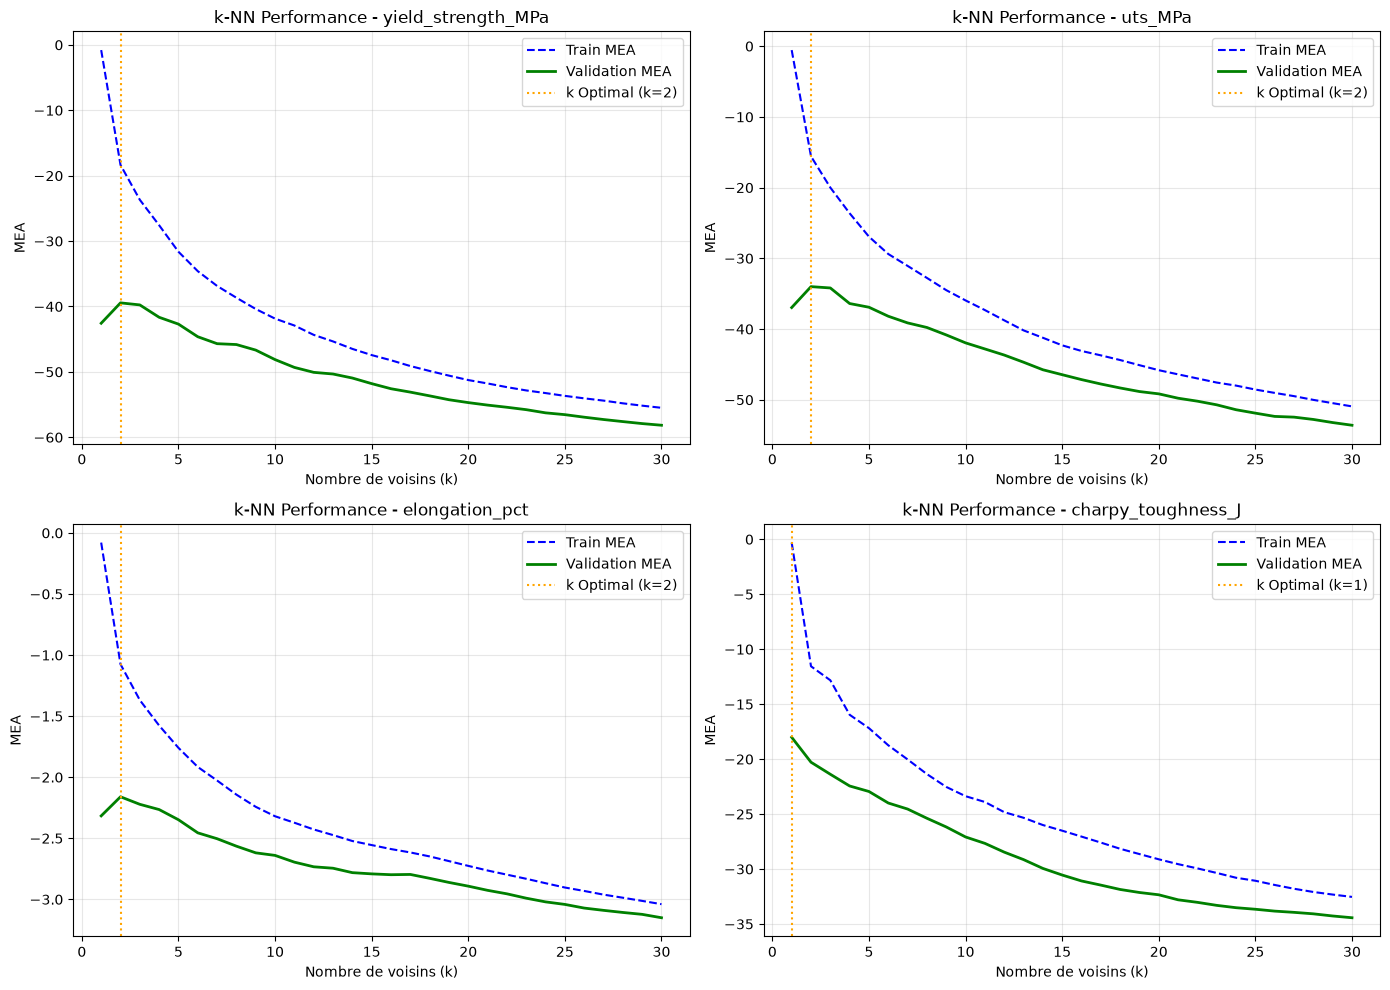

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, target in enumerate(TARGETS):
    df_hist = knn_histories[target]
    opt_k = best_k_values[target]
    
    ax = axes[idx]
    ax.plot(df_hist["k"], df_hist["train_mea"], label="Train MEA", linestyle="--", color="blue")
    ax.plot(df_hist["k"], df_hist["val_mea"], label="Validation MEA", color="green", linewidth=2)
    ax.axvline(x=opt_k, color="orange", linestyle=":", label=f"k Optimal (k={opt_k})")
    
    ax.set_title(f"k-NN Performance - {target}")
    ax.set_xlabel("Nombre de voisins (k)")
    ax.set_ylabel("MEA")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Évaluation finale et sauvegarde des résultats

In [31]:
knn_results = evaluate("kNN regression", best_knn_models, train)
knn_results

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc
0,kNN regression,yield_strength_MPa,all,620,39.481452,58.494599,2.172125,8.591705,619,102,0.700000,0.686275
1,kNN regression,yield_strength_MPa,C-Mn,552,37.298641,52.892753,2.653886,4.555939,552,102,0.700000,0.686275
2,kNN regression,yield_strength_MPa,CrMo2,30,60.771667,101.168073,57.246390,73.153471,29,0,0.000000,0.000000
3,kNN regression,yield_strength_MPa,CrMo91,38,54.381579,84.301269,31.321811,47.878647,38,0,0.000000,0.000000
4,kNN regression,uts_MPa,all,596,34.017701,52.047312,2.244293,11.070800,595,198,0.657825,0.626263
5,kNN regression,uts_MPa,C-Mn,531,31.922787,43.828152,2.034185,2.693673,531,198,0.657825,0.626263
6,kNN regression,uts_MPa,CrMo2,34,60.192647,112.773700,55.847118,80.668237,33,0,0.000000,0.000000
7,kNN regression,uts_MPa,CrMo91,31,41.193548,72.313721,23.299266,43.677208,31,0,0.000000,0.000000
8,kNN regression,elongation_pct,all,558,2.161201,2.926043,0.157954,0.342389,557,48,0.582278,0.479167
9,kNN regression,elongation_pct,C-Mn,497,2.139738,2.789060,0.172439,0.244649,497,37,0.612903,0.513514


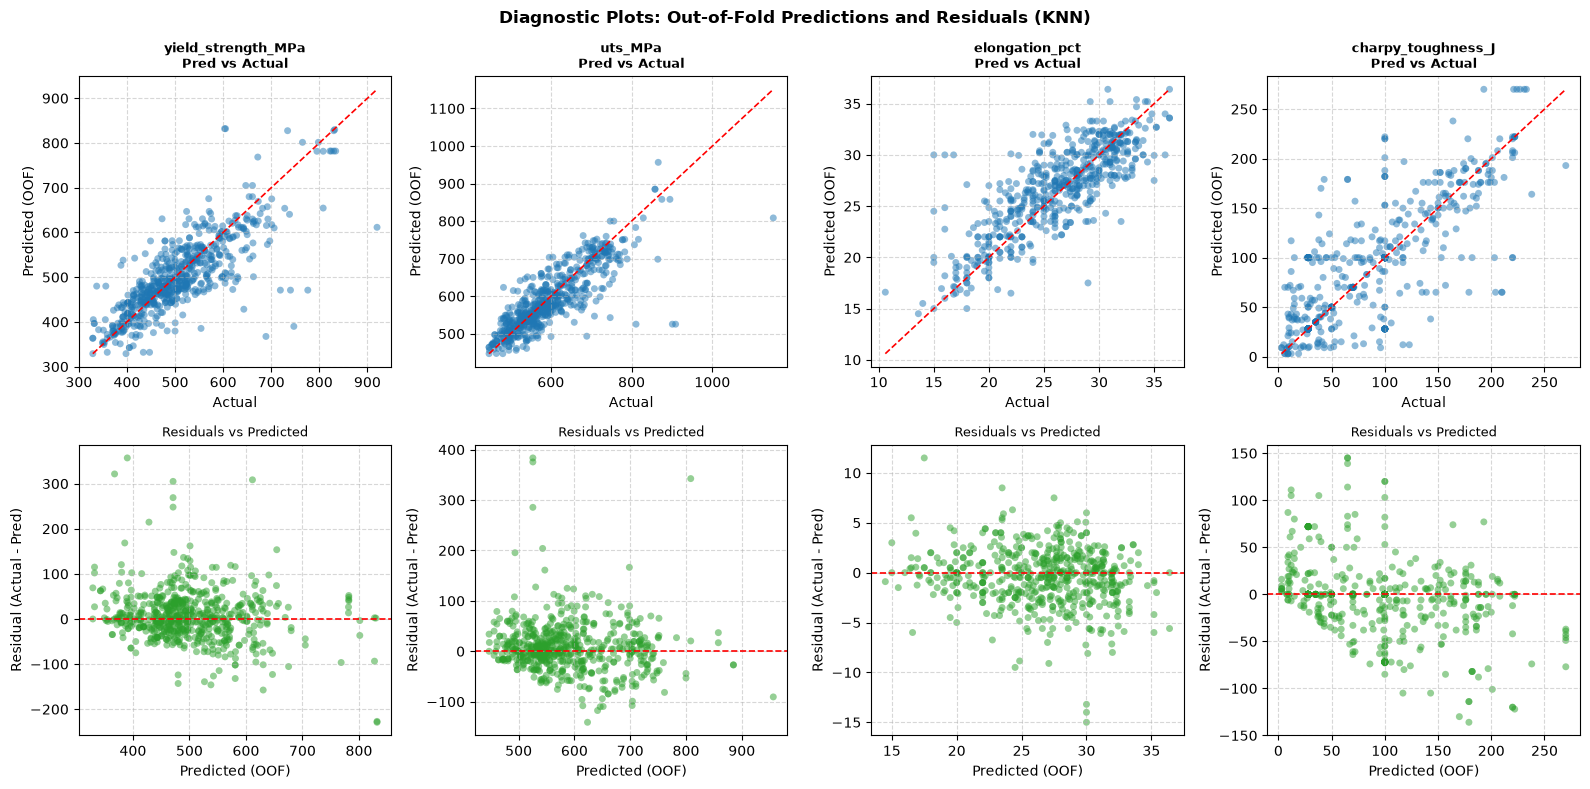

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, target in enumerate(TARGETS):
    X, y, _ = get_xy(train, target)
    oof_fwd = oof_predict(best_knn_models[target], train, target)
    y_val = y.loc[oof_fwd.index]
    pred = oof_fwd["pred"]
    resids = y_val - pred
    
    ax_sc = axes[0, i]
    ax_sc.scatter(y_val, pred, alpha=0.5, edgecolors="none", s=25, color="#1f77b4")
    min_v, max_v = min(y_val.min(), pred.min()), max(y_val.max(), pred.max())
    ax_sc.plot([min_v, max_v], [min_v, max_v], "r--", linewidth=1.2)
    ax_sc.set_title(f"{target}\nPred vs Actual", fontsize=9, fontweight="bold")
    ax_sc.set_xlabel("Actual")
    ax_sc.set_ylabel("Predicted (OOF)")
    ax_sc.grid(True, linestyle="--", alpha=0.5)
    
    ax_res = axes[1, i]
    ax_res.scatter(pred, resids, alpha=0.5, edgecolors="none", s=25, color="#2ca02c")
    ax_res.axhline(0, color="r", linestyle="--", linewidth=1.2)
    ax_res.set_title("Residuals vs Predicted", fontsize=9)
    ax_res.set_xlabel("Predicted (OOF)")
    ax_res.set_ylabel("Residual (Actual - Pred)")
    ax_res.grid(True, linestyle="--", alpha=0.5)

fig.suptitle("Diagnostic Plots: Out-of-Fold Predictions and Residuals (KNN)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


In [33]:
# Enregistrement des résultats comparatifs
results = save_results(knn_results)
models_to_compare = [
    "Baseline (mean)",
    "Linear regression",
    "Linear regression (forward)",
    "Linear regression (backward)",
    "PCR",
    "Pruned CART",
    "Bagging",
    "Random forest",
    "Extra-Trees",
    "kNN regression"
]
compared = results[results["model"].isin(models_to_compare) & (results["family"] == "all")].set_index(["model", "target"])

print("--- Regression Metrics (MAE & RMSE) ---")
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS, level="target").round(2))

print("\n--- Classification Metrics (F1_nc & recall_nc) ---")
display(compared[["F1_nc", "recall_nc"]].unstack().reindex(index=models_to_compare).reindex(columns=TARGETS + ["label"], level="target").round(2))

--- Regression Metrics (MAE & RMSE) ---


MAE                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                           72.57   73.45           4.01   
Linear regression                         52.02   45.13           2.79   
Linear regression (forward)               50.26   42.43           2.72   
Linear regression (backward)              50.30   42.26           2.69   
PCR                                       51.84   44.55           2.78   
Pruned CART                               48.24   41.78           2.60   
Bagging                                   35.24   30.86           1.95   
Random forest                             33.95   29.55           1.94   
Extra-Trees                               29.08   25.24           1.78   
kNN regression                            39.48   34.02           2.16   

                                                              RMSE          \
target                       charpy_toughness_J yield_strength_MPa uts_MPa   
model                                                                        
Baseline (mean)                           39.89              94.41   92.19   
Linear regression                         30.36              69.67   63.01   
Linear regression (forward)               25.14              67.34   59.00   
Linear regression (backward)              25.29              67.36   58.88   
PCR                                       30.36              69.50   62.74   
Pruned CART                               18.87              66.22   59.97   
Bagging                                   19.11              49.40   44.45   
Random forest                             19.09              47.46   42.30   
Extra-Trees                               17.37              42.49   38.84   
kNN regression                            18.04              58.49   52.05   

                                                                
target                       elongation_pct charpy_toughness_J  
model                                                           
Baseline (mean)                        4.85              51.73  
Linear regression                      3.60              58.54  
Linear regression (forward)            3.50              32.11  
Linear regression (backward)           3.47              31.99  
PCR                                    3.57              58.54  
Pruned CART                            3.32              32.46  
Bagging                                2.51              28.16  
Random forest                          2.51              28.39  
Extra-Trees                            2.36              27.71  
kNN regression                         2.93              34.11


--- Classification Metrics (F1_nc & recall_nc) ---


F1_nc                         \
target                       yield_strength_MPa uts_MPa elongation_pct   
model                                                                    
Baseline (mean)                            0.00    0.00           0.00   
Linear regression                          0.45    0.57           0.31   
Linear regression (forward)                0.35    0.60           0.30   
Linear regression (backward)               0.40    0.60           0.30   
PCR                                        0.43    0.60           0.29   
Pruned CART                                0.60    0.64           0.46   
Bagging                                    0.68    0.67           0.62   
Random forest                              0.63    0.68           0.59   
Extra-Trees                                0.78    0.74           0.72   
kNN regression                             0.70    0.66           0.58   

                                                               recall_nc  \
target                       charpy_toughness_J label yield_strength_MPa   
model                                                                      
Baseline (mean)                            0.00  0.00               0.00   
Linear regression                          0.65  0.52               0.33   
Linear regression (forward)                0.67  0.58               0.25   
Linear regression (backward)               0.75  0.59               0.28   
PCR                                        0.65  0.53               0.31   
Pruned CART                                0.52  0.77               0.60   
Bagging                                    0.17  0.81               0.57   
Random forest                              0.26  0.76               0.48   
Extra-Trees                                0.27  0.84               0.65   
kNN regression                             0.78  0.78               0.69   

                                                                              
target                       uts_MPa elongation_pct charpy_toughness_J label  
model                                                                         
Baseline (mean)                 0.00           0.00               0.00  0.00  
Linear regression               0.47           0.23               0.55  0.39  
Linear regression (forward)     0.49           0.23               0.52  0.43  
Linear regression (backward)    0.49           0.23               0.62  0.45  
PCR                             0.49           0.21               0.55  0.40  
Pruned CART                     0.63           0.50               0.62  0.81  
Bagging                         0.56           0.50               0.10  0.72  
Random forest                   0.54           0.44               0.17  0.64  
Extra-Trees                     0.61           0.60               0.17  0.72  
kNN regression                  0.63           0.48               0.86  0.77

La régression kNN obtient de meilleurs scores sur certaines targets, mais elle reste améliorable. Le fait que k soit proche de 1 signifie que le modèle est sensible au bruit